# Neural Networks

## Multi Layer Perceptron

As a first step, we will implement a MultiLayer Perceptron (MLP) to test it on the classic iris dataset. 

1. Load the iris dataset and split it into train and test sets 
> Check the previous pratical sessions !

2. Built a Multi Layer Perceptron with default parameters and evaluate its accuracy on test set.

3. Plot the loss curve by using the `loss_curve_` attribute of `MLPClassifier`

4. Change the `max_iter` to 100 and check the curve and the output.


In [2]:
from sklearn.datasets import load_iris
...
X_train, X_test, y_train, y_test = ...


TypeError: cannot unpack non-iterable ellipsis object

In [1]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
X,y = load_iris(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)


In [ ]:
from sklearn.neural_network import MLPClassifier
clf = 
...
print("Accuracy:", clf.score(X_test, y_test))


In [2]:
from sklearn.neural_network import MLPClassifier
clf = MLPClassifier(random_state=42,verbose=True,max_iter=1000)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
print("Accuracy:", clf.score(X_test, y_test))


Iteration 1, loss = 1.20130254
Iteration 2, loss = 1.15769483
Iteration 3, loss = 1.11903701
Iteration 4, loss = 1.08551409
Iteration 5, loss = 1.05720049
Iteration 6, loss = 1.03386633
Iteration 7, loss = 1.01499794
Iteration 8, loss = 0.99969208
Iteration 9, loss = 0.98685385
Iteration 10, loss = 0.97539047
Iteration 11, loss = 0.96437599
Iteration 12, loss = 0.95313615
Iteration 13, loss = 0.94131033
Iteration 14, loss = 0.92890318
Iteration 15, loss = 0.91601861
Iteration 16, loss = 0.90293758
Iteration 17, loss = 0.88990646
Iteration 18, loss = 0.87719143
Iteration 19, loss = 0.86490437
Iteration 20, loss = 0.85327286
Iteration 21, loss = 0.84230604
Iteration 22, loss = 0.83200234
Iteration 23, loss = 0.82218084
Iteration 24, loss = 0.81270730
Iteration 25, loss = 0.80347087
Iteration 26, loss = 0.79442390
Iteration 27, loss = 0.78547156
Iteration 28, loss = 0.77666584
Iteration 29, loss = 0.76802705
Iteration 30, loss = 0.75956193
Iteration 31, loss = 0.75132119
Iteration 32, los

In [4]:
from matplotlib import pyplot as plt
...

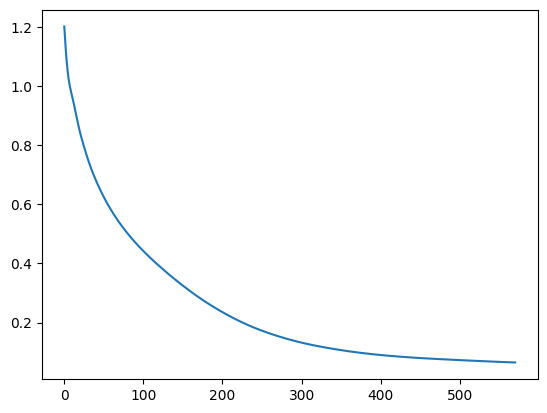

In [3]:
from matplotlib import pyplot as plt
plt.plot(clf.loss_curve_)

## Are Neural Networks better than classic ML ?

To answer this question, we will investigate if using a MLP can beat a tree based approach on the COBRA dataset seen in the previous practical session. As the results indicate that the descriptors XX work better, we will stick on this data. 

The purpose of this section is to design a fair experiment between the two methods: 
1. What are the key points to take care to have a fair comparison ?  
2. What hyperparameters will you tune ? how many values ?  
3. Write down explicly your experimental protocol

Once these points are clear for you, start your implementation of different methods. 

L'idée ici est de se poser des questions lorsque l'on compare des méthodes. Il est trés facile de faire chuter un modele et de faire "bien" marcher un autre en trichant. 
Les concepts clés à faire gaffe pour moi :
 - découpage train/valid/test commun pour toutes les méthodes
 - Réglage des hyperparamètres sur le valid
 - meme "budget" d'hyperparametres
 - Comparaison finale sur le test
 - Plusieurs runs pour avoir une std et une perf moyenne
 - comparaison à une baseline (dummyRegressor)
 - mesure d'évaluation

2. Pour xgboost, je reprends les hyperparametres du TP 2 :
- 'n_estimators':[25,50,100],
- 'learning_rate':[1e-2,5e-2,1e-1,.5]
=> 3*4 = 12 couples d'hyperparametres. Ce sera mon budget
Pour les NN, on teste l'archi et les epochs. On verra un moyen + intelligent pour gérer le nb d'epochs sur les CNN
 - max_epochs = [10,50,100,500]
 - hidden_layer_sizes = [32], [32,64,32], [32,64,128,64,32]

3. Protocol : 
split des données en 80% train, 20 % test. Pour chaque split, on test de 25 jeux d'hyperparametres tels que défini au dessus. Evaluation en utilisant une MAE sur le test set. Grid search cv avec k=5 pour trouver le meilleur jeu d'hyperparametre avec la meme mesure de perf.  

In [7]:
# Data importation 
import pickle
with open("cobra_data.pkl","rb") as f:
    data_cobra = pickle.load(f)
X_cobra_graph_atom = data_cobra["X_cobra_graph_atom"]
y_cobra = data_cobra["y_cobra"]

from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error
from tqdm import tqdm
import numpy as np

perf_mae_nn = []
perf_mae_rf = []

mlp = MLPRegressor()
param_grid_mlp = {"max_iter":[10,50,100,500],
                  "hidden_layer_sizes":[(32), (32,64,32), (32,64,128,64,32)]}
cv_mlp = GridSearchCV(mlp,param_grid_mlp,cv=5, scoring="neg_mean_absolute_error")

rf = GradientBoostingRegressor()
param_grid_rf = {"n_estimators":[25,50,100],
                 "learning_rate":[1e-2,5e-2,1e-1,.5]}
cv_rf = GridSearchCV(rf,param_grid_rf,cv=5, scoring="neg_mean_absolute_error")


for _ in tqdm(range(10)):
    X_train, X_test, y_train, y_test = train_test_split(X_cobra_graph_atom, y_cobra, test_size=0.33)
    cv_mlp.fit(X_train, y_train)
    perf_mae_nn.append(mean_absolute_error(cv_mlp.predict(X_test), y_test))
    cv_rf.fit(X_train, y_train)
    perf_mae_rf.append(mean_absolute_error(cv_rf.predict(X_test), y_test))
    
print(f"Perf moyenne NN : {np.mean(perf_mae_nn)}")
print(f"Perf moyenne RF : {np.mean(perf_mae_rf)}")


  0%|          | 0/10 [00:00<?, ?it/s]/home/bgauzere/.cache/pypoetry/virtualenvs/ia-pour-la-chimie-2XarQKld-py3.8/lib/python3.8/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (10) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/bgauzere/.cache/pypoetry/virtualenvs/ia-pour-la-chimie-2XarQKld-py3.8/lib/python3.8/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (10) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/bgauzere/.cache/pypoetry/virtualenvs/ia-pour-la-chimie-2XarQKld-py3.8/lib/python3.8/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (10) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/bgauzere/.cache/pypoetry/virtualenvs/ia-pour-la-chimie-2XarQKld-py3.8/lib/python

Perf moyenne NN : 2.1773169812598208
Perf moyenne RF : 1.7231933895978184


In [ ]:
from sklearn.model_selection import train_test_split

perf_mae_nn = []
perf_mae_xgboost = []

for _ in range(10):
    ...


# Neural Networks for Images

For this section, we will train bigger models on much more data. Let's run it on Colab to benefit from the computer ressources of Google.

Open the online notebook [here](https://colab.research.google.com/drive/1QEWLMCgIwyPaRslo-uyBBznE1BBSQzDV?usp=sharing).